# RF-DETR v1 - Showcase de resultados

## Tabela 1 - Dados do split
## Tabela 2 - Configuracao do melhor run
## Tabela 3 - Comparacao dos runs (A/B/C)
## Tabela 4 - Selecao do checkpoint campeao
## Tabela 5 - Resumo executivo de metricas
## Erro medio no val (contagem e area)
## Tabela 6 - Metricas recalculadas (checkpoint carregado)
## Tabela 7 - Relatorio por imagem
## Tabela 8 - Resumo por instancia
## Tabela 9 - Inferencia e hardware


In [41]:
from __future__ import annotations

import json
import re
import time
from pathlib import Path
from typing import Dict, List, Tuple

import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from IPython.display import Markdown, display

from rfdetr import RFDETRSegSmall

pd.set_option('display.max_columns', 200)
pd.set_option('display.width', 220)


In [42]:
def discover_repo_root(start: Path | None = None) -> Path:
    p = (start or Path.cwd()).resolve()
    while p != p.parent:
        if (p / '.git').exists() and (p / 'v2_rf_detr').exists():
            return p
        p = p.parent
    raise RuntimeError('Nao foi possivel localizar a raiz do repositorio.')


REPO_ROOT = discover_repo_root()
PROJECT_ROOT = REPO_ROOT / 'v2_rfdetr_opt_v1'
ARTIFACTS_ROOT = PROJECT_ROOT / 'artifacts'
BENCH_ROOT = ARTIFACTS_ROOT / 'benchmarks'
RUNS_ROOT = ARTIFACTS_ROOT / 'runs'
REPORTS_ROOT = ARTIFACTS_ROOT / 'reports'
IOU_VIZ_ROOT = ARTIFACTS_ROOT / 'iou_viz'
SHOWCASE_ROOT = ARTIFACTS_ROOT / 'showcase'
FIG_ROOT = SHOWCASE_ROOT / 'figures'

for p in [SHOWCASE_ROOT, FIG_ROOT]:
    p.mkdir(parents=True, exist_ok=True)

DATASET_DIR = (REPO_ROOT.parent.parent / 'dataset_v2_coco_rf_detr').resolve()
VALID_DIR = DATASET_DIR / 'valid'
VALID_ANN_PATH = VALID_DIR / '_annotations.coco.json'

IOU_THRESHOLD = 0.5
AREA_FACTOR = (50 / 72) ** 2
RUN_CHECKPOINT_EVAL = True

champion_json = BENCH_ROOT / 'overall_champion.json'
run_ranking_csv = BENCH_ROOT / 'run_ranking.csv'
leaderboard_csv = BENCH_ROOT / 'overall_leaderboard.csv'

if not champion_json.exists():
    raise FileNotFoundError(f'Arquivo nao encontrado: {champion_json}')

champion = json.loads(champion_json.read_text(encoding='utf-8'))
RUN_NAME = champion['variant']
BEST_CONF = float(champion['best_conf'])
CHECKPOINT_PATH = Path(champion['checkpoint'])
SWEEP_CSV = BENCH_ROOT / f'validation_conf_sweep_{RUN_NAME}.csv'
RUN_REPORT_DIR = REPORTS_ROOT / RUN_NAME
RUN_IOU_VIZ_DIR = IOU_VIZ_ROOT / RUN_NAME

print('RUN_NAME:       ', RUN_NAME)
print('BEST_CONF:      ', BEST_CONF)
print('CHECKPOINT_PATH:', CHECKPOINT_PATH)
print('VALID_ANN_PATH: ', VALID_ANN_PATH)
print('SHOWCASE_ROOT:  ', SHOWCASE_ROOT)


RUN_NAME:        seg_small_optA_r560_acc16_lr1e4
BEST_CONF:       0.46
CHECKPOINT_PATH: D:\projeto_placentas_clayton\dev\projeto-placentas\v2_rfdetr_opt_v1\artifacts\runs\seg_small_optA_r560_acc16_lr1e4\checkpoint_best_total.pth
VALID_ANN_PATH:  D:\projeto_placentas_clayton\dataset_v2_coco_rf_detr\valid\_annotations.coco.json
SHOWCASE_ROOT:   D:\projeto_placentas_clayton\dev\projeto-placentas\v2_rfdetr_opt_v1\artifacts\showcase


In [43]:
def ann_to_mask(ann: Dict, height: int, width: int) -> np.ndarray:
    seg = ann.get('segmentation', None)
    if not seg:
        return np.zeros((height, width), dtype=np.uint8)

    if isinstance(seg, list):
        mask = np.zeros((height, width), dtype=np.uint8)
        for poly in seg:
            pts = np.asarray(poly, dtype=np.float32).reshape(-1, 2)
            cv2.fillPoly(mask, [pts.astype(np.int32)], 1)
        return mask

    if isinstance(seg, dict):
        try:
            from pycocotools import mask as mask_utils
            return mask_utils.decode(seg).astype(np.uint8)
        except Exception:
            return np.zeros((height, width), dtype=np.uint8)

    return np.zeros((height, width), dtype=np.uint8)


def get_pred_masks_and_conf(det) -> Tuple[List[np.ndarray], List[float]]:
    masks: List[np.ndarray] = []
    confs: List[float] = []

    pred_mask = getattr(det, 'mask', None)
    pred_conf = getattr(det, 'confidence', None)

    if pred_mask is not None:
        arr = np.asarray(pred_mask)
        if arr.ndim == 2:
            masks.append((arr > 0).astype(np.uint8))
        elif arr.ndim == 3:
            for m in arr:
                masks.append((m > 0).astype(np.uint8))

    if pred_conf is not None:
        c = np.asarray(pred_conf).reshape(-1)
        confs = [float(x) for x in c]

    if len(confs) != len(masks):
        confs = [1.0] * len(masks)

    return masks, confs


def iou_binary(a: np.ndarray, b: np.ndarray) -> float:
    inter = np.logical_and(a, b).sum()
    union = np.logical_or(a, b).sum()
    return float(inter) / float(union) if union > 0 else 0.0


def greedy_match(pred_masks: List[np.ndarray], gt_masks: List[np.ndarray], iou_thr: float = 0.5):
    candidates: List[Tuple[float, int, int]] = []
    for i, pm in enumerate(pred_masks):
        for j, gm in enumerate(gt_masks):
            score = iou_binary(pm, gm)
            if score >= iou_thr:
                candidates.append((score, i, j))
    candidates.sort(key=lambda x: x[0], reverse=True)

    used_p, used_g = set(), set()
    pairs = []
    for score, i, j in candidates:
        if i in used_p or j in used_g:
            continue
        used_p.add(i)
        used_g.add(j)
        pairs.append((i, j, score))
    return pairs, used_p, used_g


if not VALID_ANN_PATH.exists():
    raise FileNotFoundError(f'Arquivo nao encontrado: {VALID_ANN_PATH}')

valid_coco = json.loads(VALID_ANN_PATH.read_text(encoding='utf-8'))
VAL_IMGS = valid_coco.get('images', [])
VAL_ANNS = valid_coco.get('annotations', [])
VAL_IMGS_BY_ID = {int(x['id']): x for x in VAL_IMGS}
VAL_ANNS_BY_IMG: Dict[int, List[Dict]] = {}
for ann in VAL_ANNS:
    VAL_ANNS_BY_IMG.setdefault(int(ann['image_id']), []).append(ann)


def get_gt_masks_for_image(img_id: int) -> Tuple[List[np.ndarray], int, int]:
    info = VAL_IMGS_BY_ID[int(img_id)]
    h, w = int(info['height']), int(info['width'])
    anns = VAL_ANNS_BY_IMG.get(int(img_id), [])
    masks = [ann_to_mask(a, h, w) for a in anns]
    return masks, h, w


## Tabela 1 - Dados do split

,Split,Images,Instances
0,train,153,4753
1,valid,27,852


## Exemplo visual GT (sem IA)

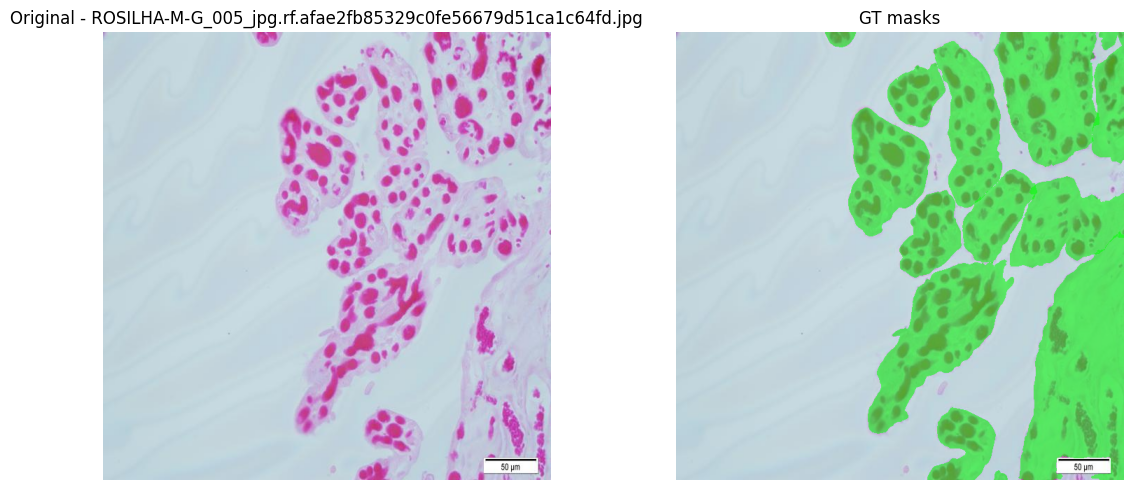

In [44]:
display(Markdown('## Tabela 1 - Dados do split'))

train_ann_path = DATASET_DIR / 'train' / '_annotations.coco.json'
train_coco = json.loads(train_ann_path.read_text(encoding='utf-8')) if train_ann_path.exists() else {'images': [], 'annotations': []}

split_df = pd.DataFrame(
    [
        {'Split': 'train', 'Images': len(train_coco.get('images', [])), 'Instances': len(train_coco.get('annotations', []))},
        {'Split': 'valid', 'Images': len(VAL_IMGS), 'Instances': len(VAL_ANNS)},
    ]
)
display(split_df)

display(Markdown('## Exemplo visual GT (sem IA)'))
sample = VAL_IMGS[0]
sample_id = int(sample['id'])
sample_name = sample['file_name']
sample_path = VALID_DIR / sample_name

img = cv2.cvtColor(cv2.imread(str(sample_path)), cv2.COLOR_BGR2RGB)
gt_masks, h, w = get_gt_masks_for_image(sample_id)

overlay = img.copy()
for gm in gt_masks:
    overlay[gm > 0] = (overlay[gm > 0] * 0.45 + np.array([0, 255, 0]) * 0.55).astype(np.uint8)

fig, ax = plt.subplots(1, 2, figsize=(12, 5))
ax[0].imshow(img)
ax[0].set_title(f'Original - {sample_name}')
ax[0].axis('off')
ax[1].imshow(overlay)
ax[1].set_title('GT masks')
ax[1].axis('off')
plt.tight_layout()
plt.show()


In [45]:
def parse_run_name(run_name: str) -> Dict[str, str]:
    m = re.match(r'seg_small_opt([A-Za-z0-9]+)_r(\d+)_acc(\d+)_lr(.+)', run_name)
    if not m:
        return {
            'Run': run_name,
            'Modelo': 'RF-DETR Seg Small',
            'Resolucao': '-',
            'Batch x Accum': '-',
            'LR': '-',
            'Gradient Checkpointing': 'On',
        }

    _, res, acc, lr_token = m.groups()
    lr = f'1e-{lr_token[2:]}' if lr_token.startswith('1e') and '-' not in lr_token else lr_token
    return {
        'Run': run_name,
        'Modelo': 'RF-DETR Seg Small',
        'Resolucao': int(res),
        'Batch x Accum': f'1 x {acc}',
        'LR': lr,
        'Gradient Checkpointing': 'On',
    }


display(Markdown('## Tabela 2 - Configuracao do melhor run'))
table2_df = pd.DataFrame([parse_run_name(RUN_NAME)])
display(table2_df)

if Path(run_ranking_csv).exists():
    ranking_df = pd.read_csv(run_ranking_csv)
else:
    ranking_df = pd.DataFrame()

display(Markdown('## Tabela 3 - Comparacao dos runs (A/B/C)'))
if not ranking_df.empty:
    comp_cols = [c for c in ['run_name', 'conf', 'f1', 'mean_iou', 'area_rel_error', 'score'] if c in ranking_df.columns]
    display(ranking_df[comp_cols].copy().round(4))
else:
    print('run_ranking.csv nao encontrado.')

display(Markdown('## Tabela 4 - Selecao do checkpoint campeao'))
table4_df = pd.DataFrame(
    [
        {
            'Modelo': champion.get('model_family', ''),
            'Run': champion.get('variant', ''),
            'Best_Conf': champion.get('best_conf', ''),
            'Checkpoint': champion.get('checkpoint', ''),
            'Weighted_Score': champion.get('weighted_score', ''),
        }
    ]
)
display(table4_df)


## Tabela 2 - Configuracao do melhor run

,Run,Modelo,Resolucao,Batch x Accum,LR,Gradient Checkpointing
0,seg_small_optA_r560_acc16_lr1e4,RF-DETR Seg Small,560,1 x 16,1e-4,On


## Tabela 3 - Comparacao dos runs (A/B/C)

,run_name,conf,f1,mean_iou,area_rel_error,score
0,seg_small_optA_r560_acc16_lr1e4,0.46,0.8991,0.8969,0.0132,0.9072
1,seg_small_optB_r504_acc16_lr1e4,0.42,0.8930,0.9021,0.0094,0.9055
2,seg_small_optC_r560_acc20_lr1e4,0.44,0.8955,0.9017,0.0348,0.9043


## Tabela 4 - Selecao do checkpoint campeao

,Modelo,Run,Best_Conf,Checkpoint,Weighted_Score
0,rfdetr_seg_small,seg_small_optA_r560_acc16_lr1e4,0.46,D:\projeto_placentas_clayton\dev\projeto-place...,0.915984


In [51]:
def benchmark_model_inference(
    infer_model,
    img_paths: List[Path],
    conf_thr: float,
    repeats: int = 3,
    warmup: int = 1,
) -> Dict[str, float]:
    """Medicao de referencia para sistema: warmup + CUDA sync + apenas predict()."""
    for _ in range(warmup):
        for p in img_paths:
            _ = infer_model.predict(str(p), threshold=float(conf_thr))

    timings = []
    peak_mem_mb = np.nan
    for _ in range(repeats):
        if torch.cuda.is_available():
            torch.cuda.empty_cache()
            torch.cuda.reset_peak_memory_stats()
            torch.cuda.synchronize()

        t0 = time.perf_counter()
        for p in img_paths:
            _ = infer_model.predict(str(p), threshold=float(conf_thr))

        if torch.cuda.is_available():
            torch.cuda.synchronize()
            peak_mem_mb = torch.cuda.max_memory_allocated() / (1024.0 ** 2)

        timings.append(time.perf_counter() - t0)

    mean_elapsed = float(np.mean(timings))
    n = max(len(img_paths), 1)
    return {
        'elapsed_sec_mean': mean_elapsed,
        'elapsed_sec_std': float(np.std(timings)),
        'sec_per_image': mean_elapsed / n,
        'images_per_sec': n / mean_elapsed if mean_elapsed > 0 else 0.0,
        'peak_vram_mb_measured': peak_mem_mb,
        'repeats': repeats,
        'warmup': warmup,
    }


def evaluate_checkpoint(ckpt_path: Path, conf_thr: float):
    infer_model = RFDETRSegSmall(pretrain_weights=str(ckpt_path))
    if hasattr(infer_model, 'optimize_for_inference'):
        try:
            infer_model.optimize_for_inference()
        except Exception:
            pass

    if torch.cuda.is_available():
        torch.cuda.reset_peak_memory_stats()

    img_paths = [VALID_DIR / info['file_name'] for info in VAL_IMGS]
    infer_bench = benchmark_model_inference(infer_model, img_paths, conf_thr)

    tp = fp = fn = 0
    ious = []
    gt_total_area = 0
    pred_total_area = 0
    pipeline_times = []
    totals_rows = []
    instance_rows = []

    iou_single_dir = SHOWCASE_ROOT / 'iou_original_overlap'
    iou_single_dir.mkdir(parents=True, exist_ok=True)

    for info in VAL_IMGS:
        img_id = int(info['id'])
        img_name = info['file_name']
        img_path = VALID_DIR / img_name

        gt_masks, h, w = get_gt_masks_for_image(img_id)
        gt_total_area += sum(int(gm.sum()) for gm in gt_masks)

        t0 = time.perf_counter()
        det = infer_model.predict(str(img_path), threshold=float(conf_thr))

        pred_masks, pred_confs = get_pred_masks_and_conf(det)
        pred_masks = [m for m, c in zip(pred_masks, pred_confs) if c >= conf_thr]
        pred_masks = [
            (cv2.resize(pm.astype(np.uint8), (w, h), interpolation=cv2.INTER_NEAREST) > 0).astype(np.uint8)
            for pm in pred_masks
        ]

        pred_total_area += sum(int(pm.sum()) for pm in pred_masks)
        pairs, used_p, used_g = greedy_match(pred_masks, gt_masks, iou_thr=IOU_THRESHOLD)
        pipeline_times.append(time.perf_counter() - t0)

        tp += len(pairs)
        fp += len(pred_masks) - len(used_p)
        fn += len(gt_masks) - len(used_g)
        ious.extend([p[2] for p in pairs])

        gt_area_total = int(sum(int(gm.sum()) for gm in gt_masks))
        pred_area_total = int(sum(int(pm.sum()) for pm in pred_masks))
        area_diff_pct = ((pred_area_total - gt_area_total) / max(gt_area_total, 1)) * 100.0

        img_bgr = cv2.imread(str(img_path))
        if img_bgr is not None:
            img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
            gt_union = np.zeros((h, w), dtype=np.uint8)
            pred_union = np.zeros((h, w), dtype=np.uint8)
            for gm in gt_masks:
                gt_union = np.logical_or(gt_union, gm).astype(np.uint8)
            for pm in pred_masks:
                pred_union = np.logical_or(pred_union, pm).astype(np.uint8)

            overlay = img_rgb.copy()
            overlay[gt_union == 1] = (overlay[gt_union == 1] * 0.5 + np.array([0, 255, 0]) * 0.5).astype(np.uint8)
            overlay[pred_union == 1] = (overlay[pred_union == 1] * 0.5 + np.array([255, 0, 0]) * 0.5).astype(np.uint8)
            overlap = np.logical_and(gt_union, pred_union)
            overlay[overlap] = (overlay[overlap] * 0.5 + np.array([255, 255, 0]) * 0.5).astype(np.uint8)

            fig, axes = plt.subplots(1, 2, figsize=(12, 5))
            axes[0].imshow(img_rgb)
            axes[0].set_title('Original')
            axes[0].axis('off')
            axes[1].imshow(overlay)
            axes[1].set_title('Overlap (GT verde, IA vermelho, intersecao amarelo)')
            axes[1].axis('off')
            fig.suptitle(f"{Path(img_name).stem} | CE={len(pred_masks)-len(gt_masks)} | AD={area_diff_pct:.1f}%")
            fig.tight_layout()
            fig.savefig(iou_single_dir / f"original_overlap_{Path(img_name).stem}.png", dpi=140, bbox_inches='tight')
            plt.close(fig)

        totals_rows.append(
            {
                'Image': img_name,
                'GT_Count': len(gt_masks),
                'AI_Count': len(pred_masks),
                'Matched': len(pairs),
                'FP': len(pred_masks) - len(pairs),
                'FN': len(gt_masks) - len(pairs),
                'Count_Error': len(pred_masks) - len(gt_masks),
                'GT_Area_px': gt_area_total,
                'AI_Area_px': pred_area_total,
                'GT_Area_um2': gt_area_total * AREA_FACTOR,
                'AI_Area_um2': pred_area_total * AREA_FACTOR,
                'Area_Diff_pct': area_diff_pct,
                'Pipeline_ms': pipeline_times[-1] * 1000.0,
            }
        )

        for p_idx, g_idx, score in pairs:
            p_area = int(pred_masks[p_idx].sum())
            g_area = int(gt_masks[g_idx].sum())
            instance_rows.append(
                {
                    'Image': img_name,
                    'Match_Type': 'TP',
                    'AI_Index': p_idx,
                    'GT_Index': g_idx,
                    'IoU': score,
                    'GT_Area_px': g_area,
                    'AI_Area_px': p_area,
                    'GT_Area_um2': g_area * AREA_FACTOR,
                    'AI_Area_um2': p_area * AREA_FACTOR,
                }
            )

        for p_idx, pm in enumerate(pred_masks):
            if p_idx in used_p:
                continue
            p_area = int(pm.sum())
            instance_rows.append(
                {
                    'Image': img_name,
                    'Match_Type': 'FP',
                    'AI_Index': p_idx,
                    'GT_Index': -1,
                    'IoU': 0.0,
                    'GT_Area_px': 0,
                    'AI_Area_px': p_area,
                    'GT_Area_um2': 0.0,
                    'AI_Area_um2': p_area * AREA_FACTOR,
                }
            )

        for g_idx, gm in enumerate(gt_masks):
            if g_idx in used_g:
                continue
            g_area = int(gm.sum())
            instance_rows.append(
                {
                    'Image': img_name,
                    'Match_Type': 'FN',
                    'AI_Index': -1,
                    'GT_Index': g_idx,
                    'IoU': 0.0,
                    'GT_Area_px': g_area,
                    'AI_Area_px': 0,
                    'GT_Area_um2': g_area * AREA_FACTOR,
                    'AI_Area_um2': 0.0,
                }
            )

    precision = tp / (tp + fp) if (tp + fp) else 0.0
    recall = tp / (tp + fn) if (tp + fn) else 0.0
    f1 = (2.0 * precision * recall / (precision + recall)) if (precision + recall) else 0.0
    mean_iou = float(np.mean(ious)) if ious else 0.0
    area_rel_error = abs(pred_total_area - gt_total_area) / max(gt_total_area, 1)
    pipeline_total = float(np.sum(pipeline_times))

    summary = {
        'run_name': RUN_NAME,
        'conf': conf_thr,
        'tp': int(tp),
        'fp': int(fp),
        'fn': int(fn),
        'precision': precision,
        'recall': recall,
        'f1': f1,
        'mean_iou': mean_iou,
        'gt_total_area_px': int(gt_total_area),
        'pred_total_area_px': int(pred_total_area),
        'area_rel_error': area_rel_error,
        'sec_per_image': infer_bench['sec_per_image'],
        'images_per_sec': infer_bench['images_per_sec'],
        'infer_elapsed_sec_mean': infer_bench['elapsed_sec_mean'],
        'infer_elapsed_sec_std': infer_bench['elapsed_sec_std'],
        'pipeline_sec_per_image': pipeline_total / max(len(VAL_IMGS), 1),
        'pipeline_images_per_sec': (len(VAL_IMGS) / pipeline_total) if pipeline_total > 0 else 0.0,
        'peak_vram_mb_measured': infer_bench['peak_vram_mb_measured'],
        'benchmark_repeats': infer_bench['repeats'],
        'benchmark_warmup': infer_bench['warmup'],
    }

    return summary, pd.DataFrame(totals_rows), pd.DataFrame(instance_rows)


summary_json = SHOWCASE_ROOT / 'showcase_summary.json'
totals_csv = SHOWCASE_ROOT / 'placenta_totals_report_rfdetr_showcase.csv'
inst_csv = SHOWCASE_ROOT / 'placenta_instance_report_rfdetr_showcase.csv'

if RUN_CHECKPOINT_EVAL:
    summary, totals_df, inst_df = evaluate_checkpoint(CHECKPOINT_PATH, BEST_CONF)

    gt_count_total = int(totals_df['GT_Count'].sum())
    ai_count_total = int(totals_df['AI_Count'].sum())
    summary['mean_abs_count_error'] = float(totals_df['Count_Error'].abs().mean())
    summary['mean_count_error'] = float(totals_df['Count_Error'].mean())
    summary['count_rel_error'] = abs(ai_count_total - gt_count_total) / max(gt_count_total, 1)
    summary['mean_abs_area_diff_pct'] = float(totals_df['Area_Diff_pct'].abs().mean())
    summary['mean_area_diff_pct'] = float(totals_df['Area_Diff_pct'].mean())
    summary['gt_count_total'] = gt_count_total
    summary['ai_count_total'] = ai_count_total

    totals_df.to_csv(totals_csv, index=False)
    inst_df.to_csv(inst_csv, index=False)
    summary_json.write_text(json.dumps(summary, indent=2), encoding='utf-8')
else:
    summary = json.loads(summary_json.read_text(encoding='utf-8'))
    totals_df = pd.read_csv(totals_csv)
    inst_df = pd.read_csv(inst_csv)

display(Markdown('## Tabela 5 - Resumo executivo de metricas'))
table1_df = pd.DataFrame(
    [
        {
            'F1_instancia': summary['f1'],
            'Mean_IoU': summary['mean_iou'],
            'Sec_por_imagem_modelo': summary['sec_per_image'],
            'Img_por_seg_modelo': summary['images_per_sec'],
            'VRAM_MB_medida': summary['peak_vram_mb_measured'],
        }
    ]
)
display(table1_df.round(4))

display(Markdown('## Erro medio no val (contagem e area)'))
error_val_df = pd.DataFrame(
    [
        {
            'Erro_medio_abs_contagem_por_imagem': summary.get('mean_abs_count_error', totals_df['Count_Error'].abs().mean()),
            'Erro_medio_contagem_por_imagem': summary.get('mean_count_error', totals_df['Count_Error'].mean()),
            'Erro_contagem_total_val_pct': summary.get('count_rel_error', np.nan) * 100.0,
            'Erro_medio_abs_area_por_imagem_pct': summary.get('mean_abs_area_diff_pct', totals_df['Area_Diff_pct'].abs().mean()),
            'Erro_area_total_val_pct': summary['area_rel_error'] * 100.0,
            'GT_Count_total': summary.get('gt_count_total', totals_df['GT_Count'].sum()),
            'AI_Count_total': summary.get('ai_count_total', totals_df['AI_Count'].sum()),
        }
    ]
)
display(error_val_df.round(4))

display(Markdown('## Tabela 6 - Metricas recalculadas (checkpoint carregado)'))
table5_df = pd.DataFrame([summary])[['run_name', 'conf', 'tp', 'fp', 'fn', 'precision', 'recall', 'f1', 'mean_iou', 'gt_total_area_px', 'pred_total_area_px', 'area_rel_error', 'sec_per_image', 'images_per_sec']]
display(table5_df.round(4))


[2026-05-28 21:03:23] [WARNING] rf-detr - Using a different number of positional encodings than DINOv2, which means we're not loading DINOv2 backbone weights. This is not a problem if finetuning a pretrained RF-DETR model.
[2026-05-28 21:03:23] [WARNING] rf-detr - Using patch size 12 instead of 14, which means we're not loading DINOv2 backbone weights. This is not a problem if finetuning a pretrained RF-DETR model.


## Tabela 5 - Resumo executivo de metricas

,F1_instancia,Mean_IoU,Sec_por_imagem_modelo,Img_por_seg_modelo,VRAM_MB_medida
0,0.8991,0.8963,0.0763,13.0993,1122.5469


## Erro medio no val (contagem e area)

,Erro_medio_abs_contagem_por_imagem,Erro_medio_contagem_por_imagem,Erro_contagem_total_val_pct,Erro_medio_abs_area_por_imagem_pct,Erro_area_total_val_pct,GT_Count_total,AI_Count_total
0,1.8889,-0.3333,1.0563,5.7557,2.9841,852,843


## Tabela 6 - Metricas recalculadas (checkpoint carregado)

,run_name,conf,tp,fp,fn,precision,recall,f1,mean_iou,gt_total_area_px,pred_total_area_px,area_rel_error,sec_per_image,images_per_sec
0,seg_small_optA_r560_acc16_lr1e4,0.46,762,81,90,0.9039,0.8944,0.8991,0.8963,4105313,3982807,0.0298,0.0763,13.0993


In [47]:
display(Markdown('## Tabela 7 - Relatorio por imagem'))
table6_cols = ['Image', 'GT_Count', 'AI_Count', 'Matched', 'FP', 'FN', 'Count_Error', 'GT_Area_um2', 'AI_Area_um2', 'Area_Diff_pct', 'Pipeline_ms']
table6_df = totals_df[table6_cols].copy()
table6_df['abs_count_error'] = table6_df['Count_Error'].abs()
table6_df['abs_area_diff_pct'] = table6_df['Area_Diff_pct'].abs()
table6_df = table6_df.sort_values(['abs_count_error', 'abs_area_diff_pct'], ascending=[False, False]).drop(columns=['abs_count_error', 'abs_area_diff_pct'])
display(table6_df.round(4))

display(Markdown('## Tabela 8 - Resumo por instancia'))
type_counts = inst_df['Match_Type'].value_counts().to_dict()
n_total = len(inst_df)
tp_pct = (type_counts.get('TP', 0) / max(n_total, 1)) * 100.0
fp_pct = (type_counts.get('FP', 0) / max(n_total, 1)) * 100.0
fn_pct = (type_counts.get('FN', 0) / max(n_total, 1)) * 100.0
mean_iou_tp = inst_df.loc[inst_df['Match_Type'] == 'TP', 'IoU'].mean() if n_total else 0.0

table7_df = pd.DataFrame(
    [
        {
            'Instancias_TP': type_counts.get('TP', 0),
            'Instancias_FP': type_counts.get('FP', 0),
            'Instancias_FN': type_counts.get('FN', 0),
            'TP_pct': tp_pct,
            'FP_pct': fp_pct,
            'FN_pct': fn_pct,
            'Mean_IoU_TP': mean_iou_tp,
        }
    ]
)
display(table7_df.round(4))

best3 = table6_df.assign(score=(table6_df['Count_Error'].abs() + table6_df['Area_Diff_pct'].abs())).sort_values('score', ascending=True).head(3).drop(columns=['score'])
worst3 = table6_df.assign(score=(table6_df['Count_Error'].abs() + table6_df['Area_Diff_pct'].abs())).sort_values('score', ascending=False).head(3).drop(columns=['score'])

display(Markdown('## Top 3 melhores imagens'))
display(best3.round(4))
display(Markdown('## Top 3 piores imagens'))
display(worst3.round(4))


## Tabela 7 - Relatorio por imagem

,Image,GT_Count,AI_Count,Matched,FP,FN,Count_Error,GT_Area_um2,AI_Area_um2,Area_Diff_pct,Pipeline_ms
19,TP-G_008_jpg.rf.7ce2f84776589571f8d07c60f1c4e6...,33,27,27,0,6,-6,66115.9336,65096.4506,-1.5420,1846.5235
10,ROSILHA-M-G_001_jpg.rf.3dab74a9f6c203f6aca8afc...,18,22,18,4,0,4,31875.9645,33761.5741,5.9155,952.2447
16,TP-G_010_jpg.rf.5c8b394cdec2d68bae00b4eb6679ec...,37,34,32,2,5,-3,69605.0347,59156.5394,-15.0111,2503.3541
24,TOSTADA-B_003_jpg.rf.ef070508fe8cf028db79cd039...,26,29,23,6,3,3,51870.6597,54608.8927,5.2790,1585.7793
22,TORDILHA-B_012_jpg.rf.0b5caafb1952d960be9aa54f...,41,44,39,5,2,3,63211.3233,64062.9823,1.3473,3478.4111
23,ROSILHA-M-D_006_jpg.rf.de71085683e9c7eb460be0f...,39,36,34,2,5,-3,64318.0941,63788.5802,-0.8233,2761.3009
5,TORDILHA-B_009_jpg.rf.5902113a7929ec9592dc2b09...,48,50,46,4,2,2,49778.1636,52894.4830,6.2604,4386.0102
20,ZAZA-D_004_jpg.rf.02ed2d595bd7bc4d5f40bda7d3f8...,35,33,32,1,3,-2,77297.9360,72612.3650,-6.0617,2271.8784
1,ZAZA-G_010_jpg.rf.cd14098445a0a54c10014aaa7d8f...,29,27,27,0,2,-2,55770.6404,52750.2894,-5.4157,1465.7173
21,ROSILHA-M-B_009_jpg.rf.d2aa8881a0b4f54b4bdb893...,44,42,40,2,4,-2,84714.0239,81187.3071,-4.1631,3723.2874


## Tabela 8 - Resumo por instancia

,Instancias_TP,Instancias_FP,Instancias_FN,TP_pct,FP_pct,FN_pct,Mean_IoU_TP
0,762,81,90,81.672,8.6817,9.6463,0.8963


## Top 3 melhores imagens

,Image,GT_Count,AI_Count,Matched,FP,FN,Count_Error,GT_Area_um2,AI_Area_um2,Area_Diff_pct,Pipeline_ms
9,ZAZA-B_008_jpg.rf.92ad451b5359143319a46e599a02...,28,27,23,4,5,-1,95175.5401,94223.5725,-1.0002,1427.3889
8,ZAINA-679-B_011_jpg.rf.27d46a055eff6f5810ec4c5...,24,23,23,0,1,-1,108871.5278,107440.6829,-1.3143,1186.2853
11,TORDILHA-B_010_jpg.rf.698124083a3806b10e86f630...,31,33,30,3,1,2,69545.7176,69770.9298,0.3238,1835.5356


## Top 3 piores imagens

,Image,GT_Count,AI_Count,Matched,FP,FN,Count_Error,GT_Area_um2,AI_Area_um2,Area_Diff_pct,Pipeline_ms
17,TOSTADA-B_006_jpg.rf.fd9a20fd791843647a700cdeb...,24,23,19,4,5,-1,57947.5309,43634.2593,-24.7004,1235.0224
16,TP-G_010_jpg.rf.5c8b394cdec2d68bae00b4eb6679ec...,37,34,32,2,5,-3,69605.0347,59156.5394,-15.0111,2503.3541
7,TORDILHA-D_006_jpg.rf.d879d44ef1add0b327aa39f6...,35,36,27,9,8,1,106583.7191,90737.3650,-14.8675,2581.8028


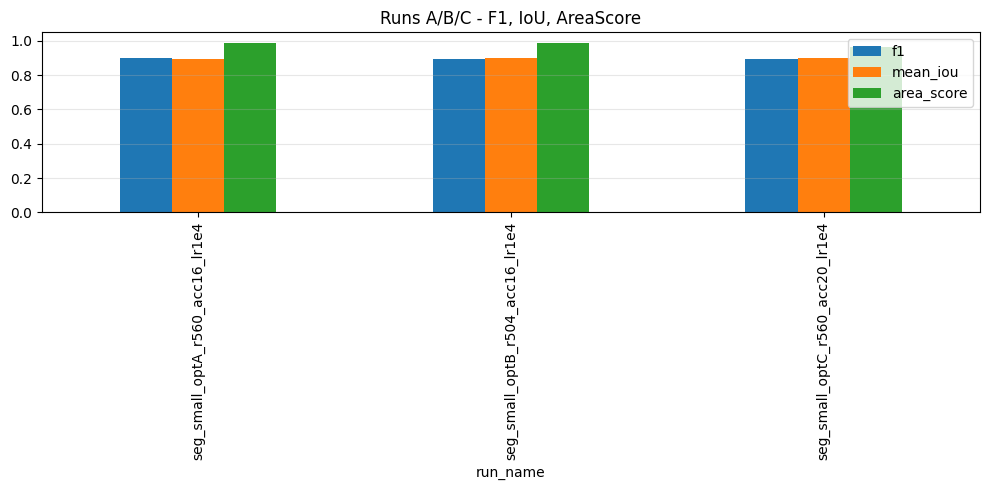

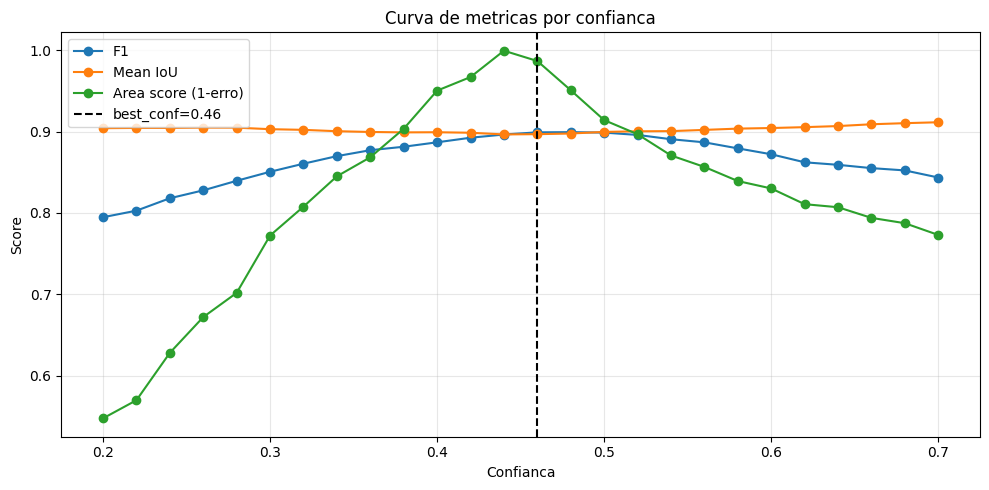

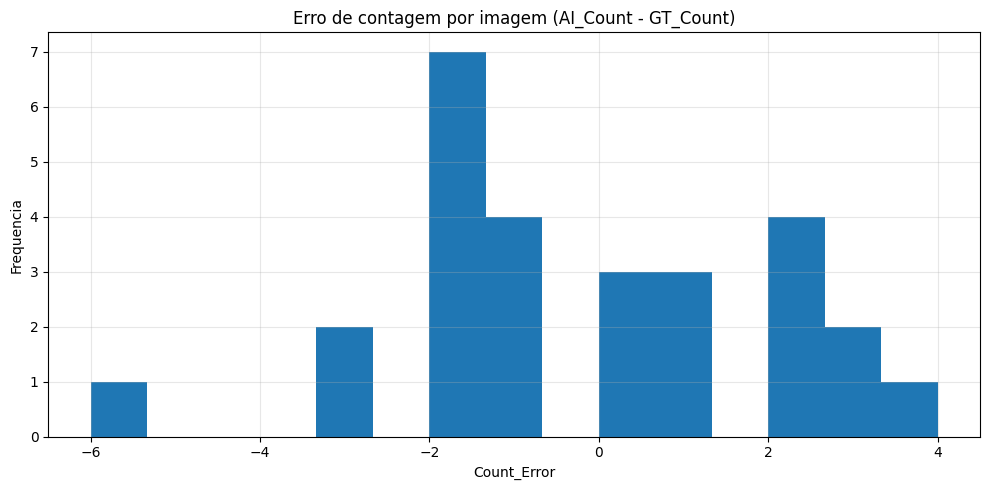

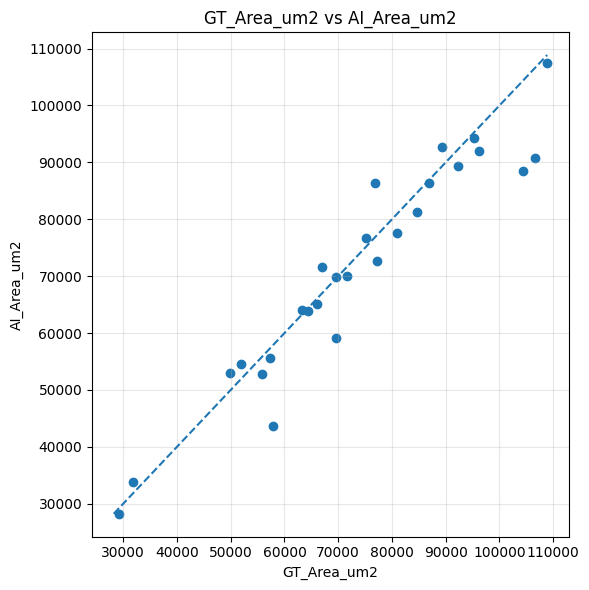

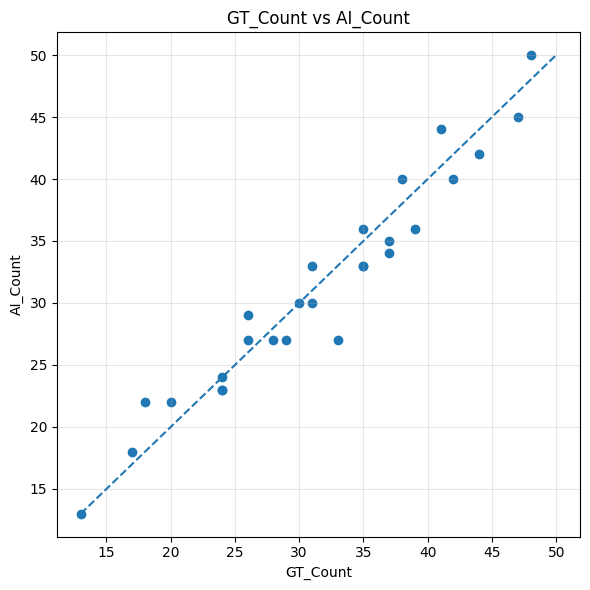

In [48]:
def save_current_fig(path: Path):
    path.parent.mkdir(parents=True, exist_ok=True)
    plt.savefig(path, dpi=140, bbox_inches='tight')


if SWEEP_CSV.exists():
    sweep_df = pd.read_csv(SWEEP_CSV)
else:
    sweep_df = pd.DataFrame()

if not ranking_df.empty:
    bars_df = ranking_df[['run_name', 'f1', 'mean_iou', 'area_rel_error']].copy()
    bars_df['area_score'] = 1.0 - bars_df['area_rel_error']
    bars_df = bars_df.set_index('run_name')

    fig = bars_df[['f1', 'mean_iou', 'area_score']].plot(kind='bar', figsize=(10, 5), title='Runs A/B/C - F1, IoU, AreaScore').get_figure()
    plt.ylim(0.0, 1.05)
    plt.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    save_current_fig(FIG_ROOT / 'run_comparison_bars.png')
    plt.show()

if not sweep_df.empty:
    # Garante curva monotona no eixo X (confianca)
    sweep_plot = sweep_df.sort_values('conf').drop_duplicates(subset=['conf'], keep='last').copy()

    plt.figure(figsize=(10, 5))
    plt.plot(sweep_plot['conf'], sweep_plot['f1'], marker='o', label='F1')
    plt.plot(sweep_plot['conf'], sweep_plot['mean_iou'], marker='o', label='Mean IoU')
    if 'area_rel_error' in sweep_plot.columns:
        plt.plot(sweep_plot['conf'], 1.0 - sweep_plot['area_rel_error'], marker='o', label='Area score (1-erro)')
    plt.axvline(BEST_CONF, linestyle='--', color='black', label=f'best_conf={BEST_CONF:.2f}')
    plt.title('Curva de metricas por confianca')
    plt.xlabel('Confianca')
    plt.ylabel('Score')
    plt.grid(alpha=0.3)
    plt.legend()
    plt.tight_layout()
    save_current_fig(FIG_ROOT / 'conf_sweep_curve.png')
    plt.show()

plt.figure(figsize=(10, 5))
plt.hist(totals_df['Count_Error'], bins=15)
plt.title('Erro de contagem por imagem (AI_Count - GT_Count)')
plt.xlabel('Count_Error')
plt.ylabel('Frequencia')
plt.grid(alpha=0.3)
plt.tight_layout()
save_current_fig(FIG_ROOT / 'count_error_hist.png')
plt.show()

plt.figure(figsize=(6, 6))
x = totals_df['GT_Area_um2'].to_numpy()
y = totals_df['AI_Area_um2'].to_numpy()
plt.scatter(x, y)
mn, mx = float(min(x.min(), y.min())), float(max(x.max(), y.max()))
plt.plot([mn, mx], [mn, mx], linestyle='--')
plt.title('GT_Area_um2 vs AI_Area_um2')
plt.xlabel('GT_Area_um2')
plt.ylabel('AI_Area_um2')
plt.grid(alpha=0.3)
plt.tight_layout()
save_current_fig(FIG_ROOT / 'area_scatter.png')
plt.show()

plt.figure(figsize=(6, 6))
x = totals_df['GT_Count'].to_numpy()
y = totals_df['AI_Count'].to_numpy()
plt.scatter(x, y)
mn, mx = float(min(x.min(), y.min())), float(max(x.max(), y.max()))
plt.plot([mn, mx], [mn, mx], linestyle='--')
plt.title('GT_Count vs AI_Count')
plt.xlabel('GT_Count')
plt.ylabel('AI_Count')
plt.grid(alpha=0.3)
plt.tight_layout()
save_current_fig(FIG_ROOT / 'count_scatter.png')
plt.show()


In [49]:
display(Markdown('## Tabela 9 - Inferencia e hardware'))

bench_json_raw = str(champion.get('inference_benchmark_json', '')).strip()
bench_json_path = Path(bench_json_raw) if bench_json_raw else None
rows = []

rows.append(
    {
        'Cenario': 'modelo_sistema (usar este)',
        'O_que_mede': 'predict() com warmup + CUDA sync',
        'Sec_por_imagem': summary.get('sec_per_image', np.nan),
        'Img_por_seg': summary.get('images_per_sec', np.nan),
        'Peak_GPU_MB': summary.get('peak_vram_mb_measured', np.nan),
        'Conf': summary.get('conf', np.nan),
    }
)

rows.append(
    {
        'Cenario': 'pipeline_analise',
        'O_que_mede': 'predict + mascaras + match (sem salvar PNG)',
        'Sec_por_imagem': summary.get('pipeline_sec_per_image', np.nan),
        'Img_por_seg': summary.get('pipeline_images_per_sec', np.nan),
        'Peak_GPU_MB': np.nan,
        'Conf': summary.get('conf', np.nan),
    }
)

if bench_json_path is not None and bench_json_path.is_file():
    b = json.loads(bench_json_path.read_text(encoding='utf-8'))
    n_imgs = max(int(b.get('n_images', len(VAL_IMGS))), 1)
    elapsed_mean = float(b.get('elapsed_sec_mean', np.nan))
    rows.append(
        {
            'Cenario': 'benchmark_historico_train_eval',
            'O_que_mede': 'benchmark salvo no treino',
            'Sec_por_imagem': elapsed_mean / n_imgs if np.isfinite(elapsed_mean) else np.nan,
            'Img_por_seg': b.get('images_per_sec', np.nan),
            'Peak_GPU_MB': b.get('peak_gpu_mem_mb', b.get('peak_gpu_mb', np.nan)),
            'Conf': b.get('conf', np.nan),
        }
    )

display(pd.DataFrame(rows).round(4))


## Tabela 9 - Inferencia e hardware

,Cenario,O_que_mede,Sec_por_imagem,Img_por_seg,Peak_GPU_MB,Conf
0,modelo_sistema (usar este),predict() com warmup + CUDA sync,0.0731,13.6861,1122.5459,0.46
1,pipeline_analise,predict + mascaras + match (sem salvar PNG),2.1077,0.4745,NaN,0.46


## Imagens individuais - Original x Overlap

,arquivo,caminho
0,original_overlap_ROSILHA-M-B_003_jpg.rf.863a24...,D:\projeto_placentas_clayton\dev\projeto-place...
1,original_overlap_ROSILHA-M-B_009_jpg.rf.d2aa88...,D:\projeto_placentas_clayton\dev\projeto-place...
2,original_overlap_ROSILHA-M-D_006_jpg.rf.de7108...,D:\projeto_placentas_clayton\dev\projeto-place...
3,original_overlap_ROSILHA-M-D_009_jpg.rf.b52035...,D:\projeto_placentas_clayton\dev\projeto-place...
4,original_overlap_ROSILHA-M-G_001_jpg.rf.3dab74...,D:\projeto_placentas_clayton\dev\projeto-place...
5,original_overlap_ROSILHA-M-G_005_jpg.rf.afae2f...,D:\projeto_placentas_clayton\dev\projeto-place...
6,original_overlap_ROSILHA-M-G_017_jpg.rf.85fc7b...,D:\projeto_placentas_clayton\dev\projeto-place...
7,original_overlap_TORDILHA-B_009_jpg.rf.5902113...,D:\projeto_placentas_clayton\dev\projeto-place...
8,original_overlap_TORDILHA-B_010_jpg.rf.6981240...,D:\projeto_placentas_clayton\dev\projeto-place...
9,original_overlap_TORDILHA-B_012_jpg.rf.0b5caaf...,D:\projeto_placentas_clayton\dev\projeto-place...


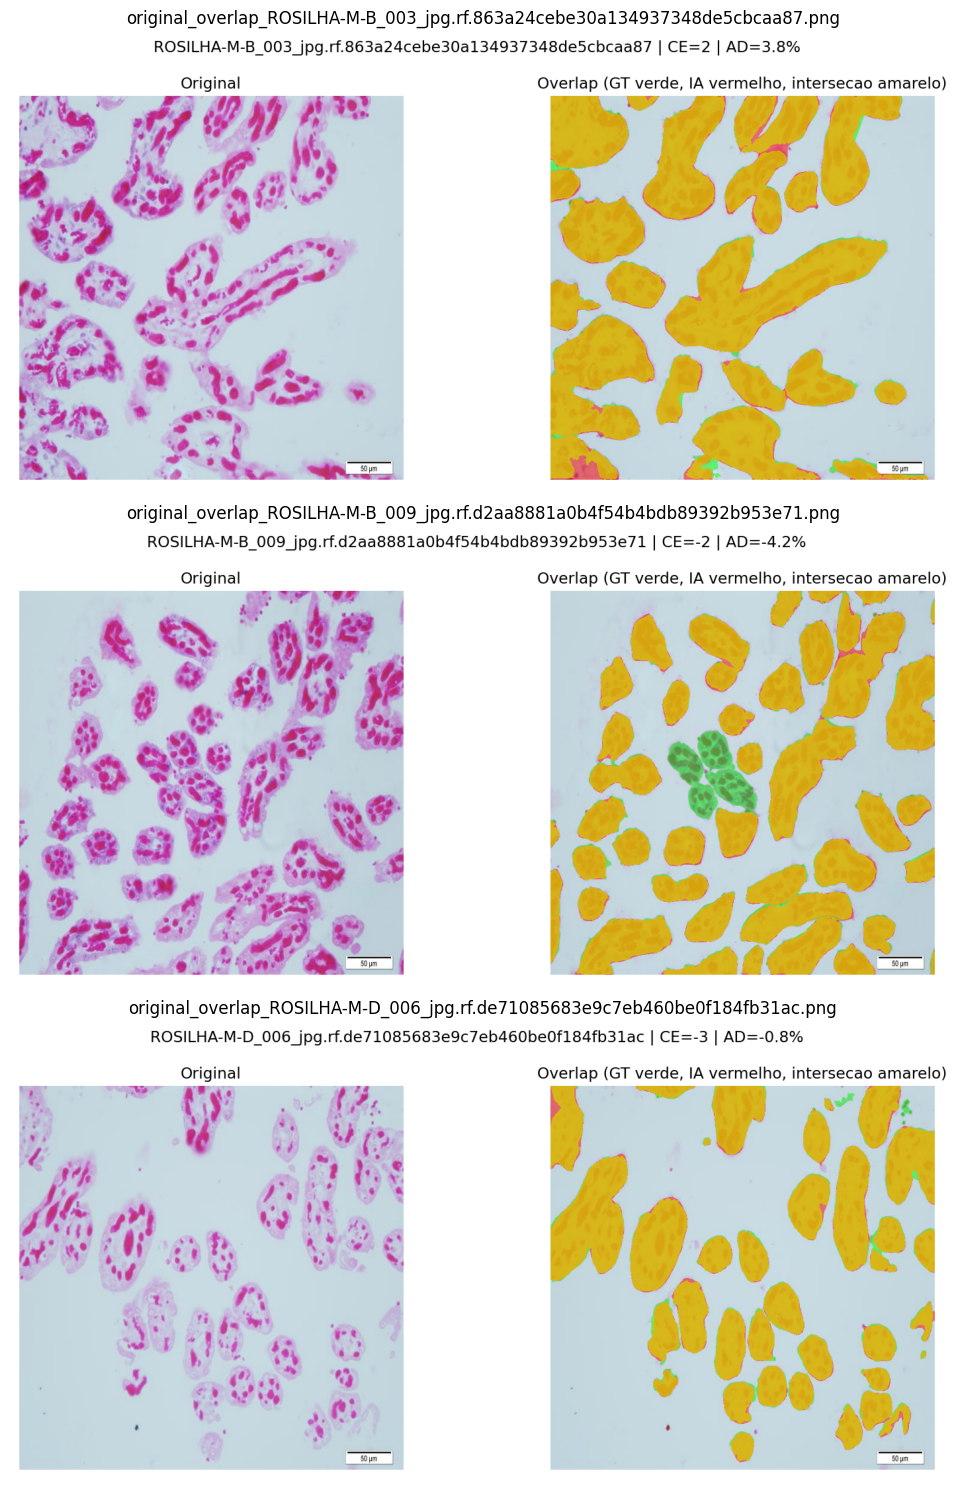

Pasta imagens individuais: D:\projeto_placentas_clayton\dev\projeto-placentas\v2_rfdetr_opt_v1\artifacts\showcase\iou_original_overlap
Figuras exportadas em: D:\projeto_placentas_clayton\dev\projeto-placentas\v2_rfdetr_opt_v1\artifacts\showcase\figures
Resumo JSON: D:\projeto_placentas_clayton\dev\projeto-placentas\v2_rfdetr_opt_v1\artifacts\showcase\showcase_summary.json
Totais CSV: D:\projeto_placentas_clayton\dev\projeto-placentas\v2_rfdetr_opt_v1\artifacts\showcase\placenta_totals_report_rfdetr_showcase.csv
Instancias CSV: D:\projeto_placentas_clayton\dev\projeto-placentas\v2_rfdetr_opt_v1\artifacts\showcase\placenta_instance_report_rfdetr_showcase.csv


In [50]:
display(Markdown('## Imagens individuais - Original x Overlap'))

iou_single_dir = SHOWCASE_ROOT / 'iou_original_overlap'
iou_files = sorted(iou_single_dir.glob('original_overlap_*.png'))

if len(iou_files) == 0:
    print('Nenhuma imagem individual encontrada. Rode novamente a celula de avaliacao do checkpoint.')
else:
    iou_df = pd.DataFrame({'arquivo': [p.name for p in iou_files], 'caminho': [str(p) for p in iou_files]})
    display(iou_df)

    preview_n = min(3, len(iou_files))
    fig, axes = plt.subplots(preview_n, 1, figsize=(14, 5 * preview_n))
    if preview_n == 1:
        axes = [axes]
    for ax, p in zip(axes, iou_files[:preview_n]):
        img = cv2.cvtColor(cv2.imread(str(p)), cv2.COLOR_BGR2RGB)
        ax.imshow(img)
        ax.set_title(p.name)
        ax.axis('off')
    plt.tight_layout()
    plt.show()

print('Pasta imagens individuais:', iou_single_dir)
print('Figuras exportadas em:', FIG_ROOT)
print('Resumo JSON:', summary_json)
print('Totais CSV:', totals_csv)
print('Instancias CSV:', inst_csv)
